<h1>Importing Librairies</h1>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score

In [2]:
train_df = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
train_df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [4]:
train_df.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442235,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [5]:
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()[1:]
print(numerical_cols)

['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_paid_back']


In [6]:
categorical_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_cols)

['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']


Plotting 6 numerical features and 6 categorical features


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


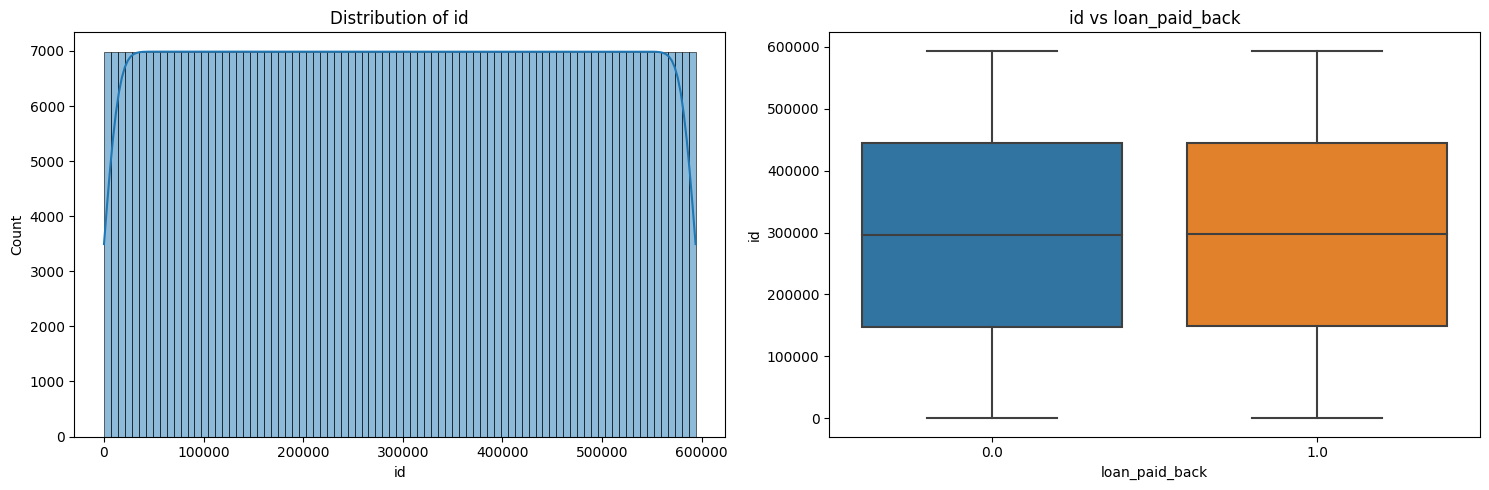

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


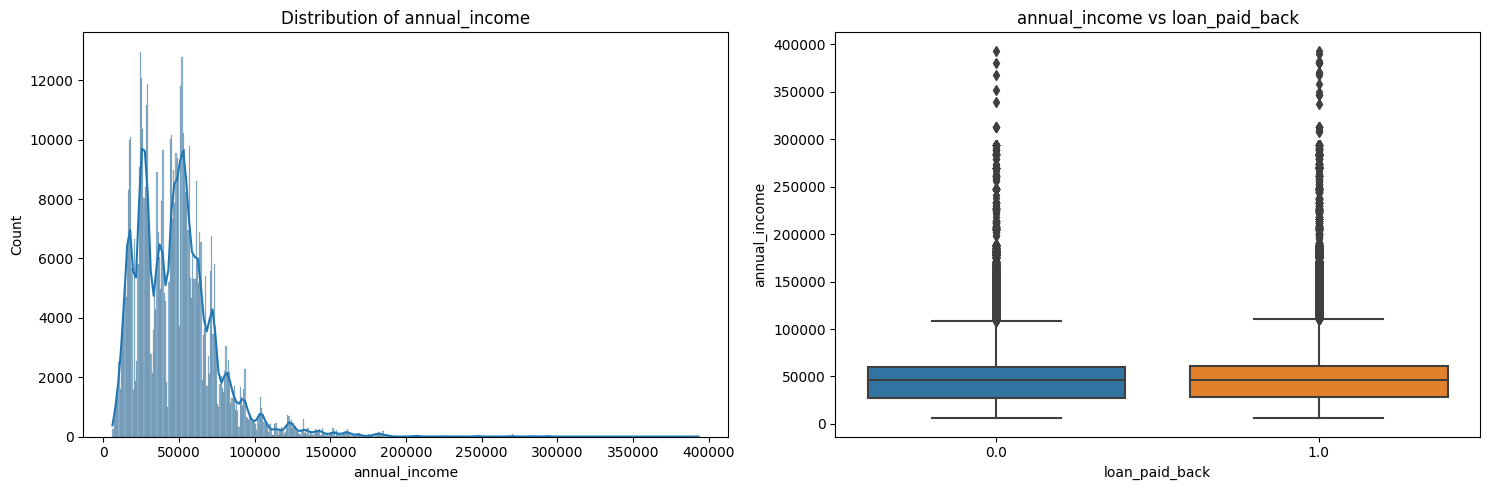

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


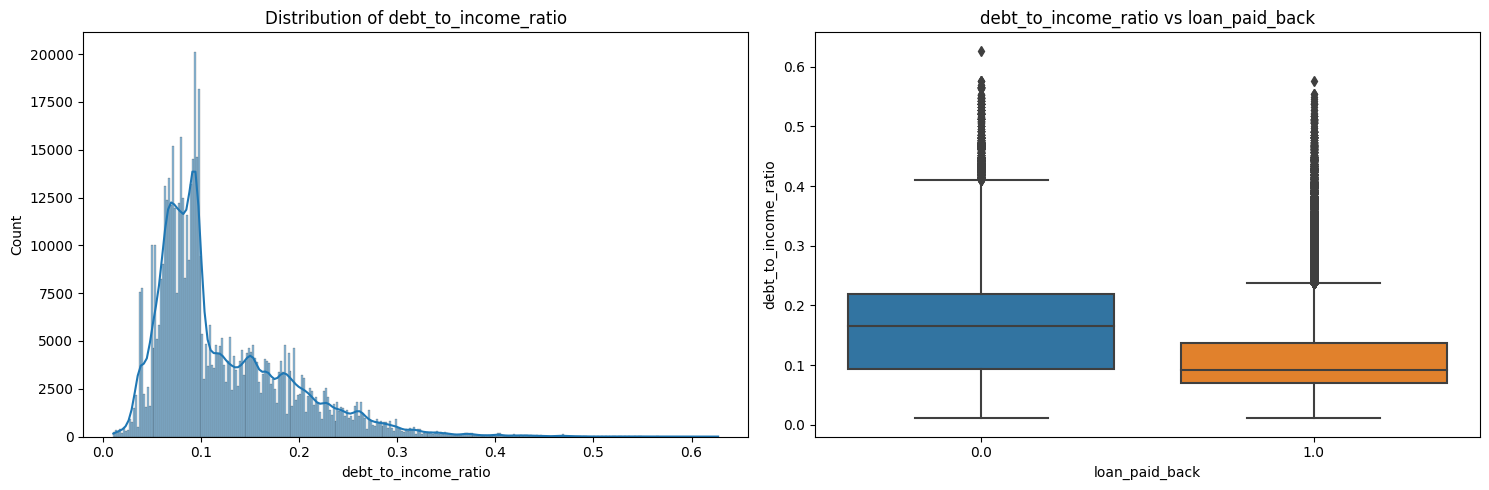

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


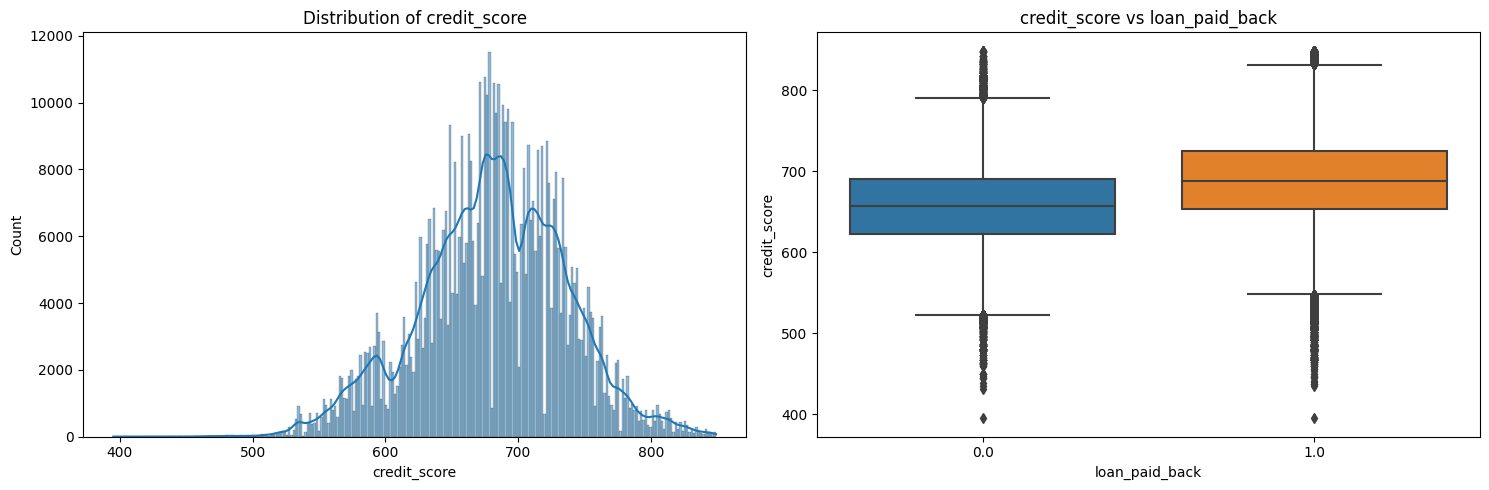

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


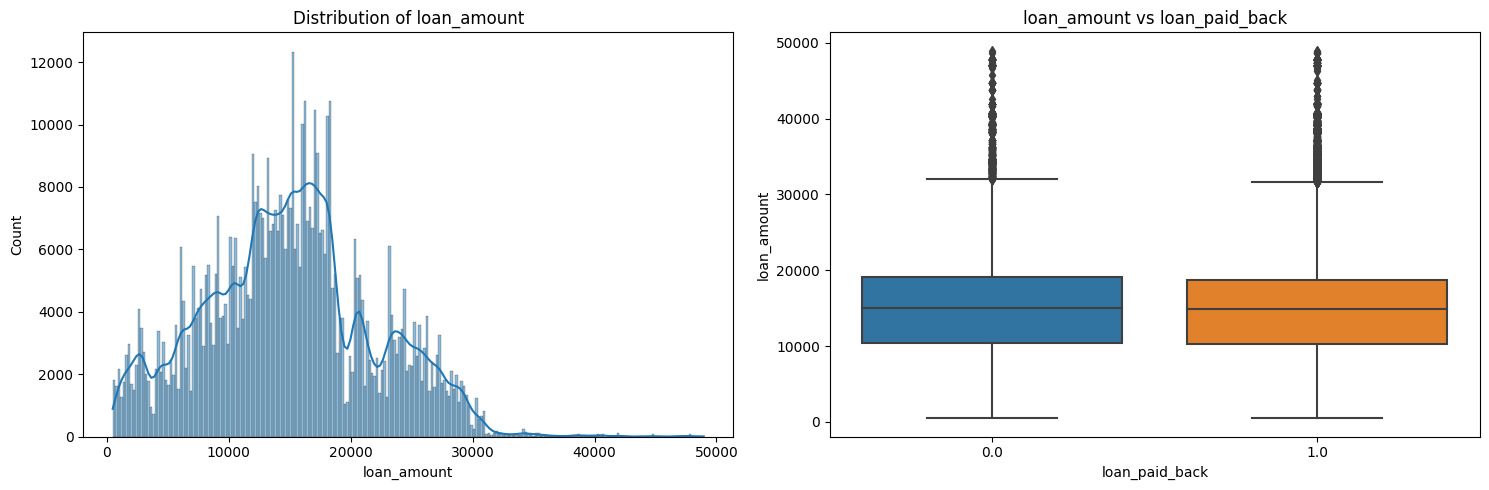

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


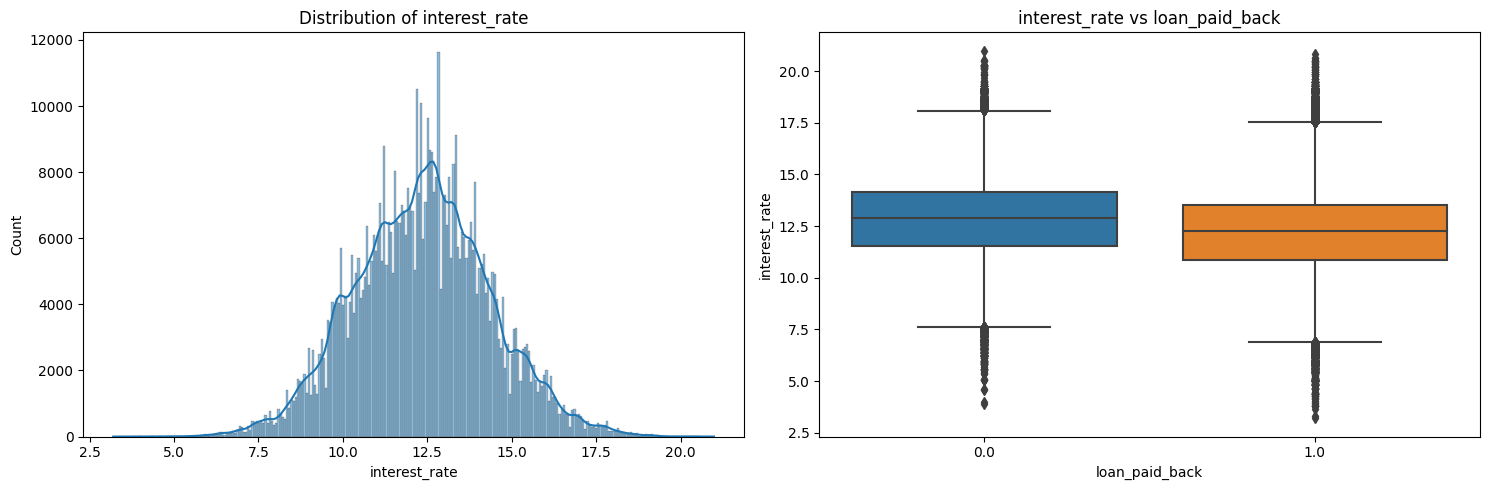

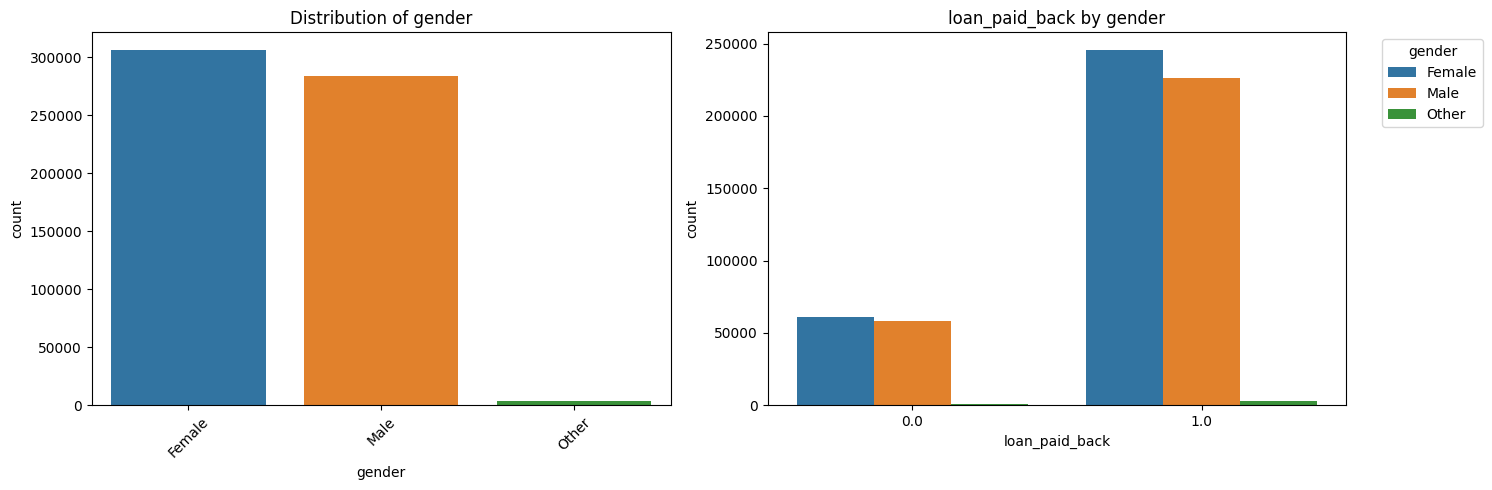

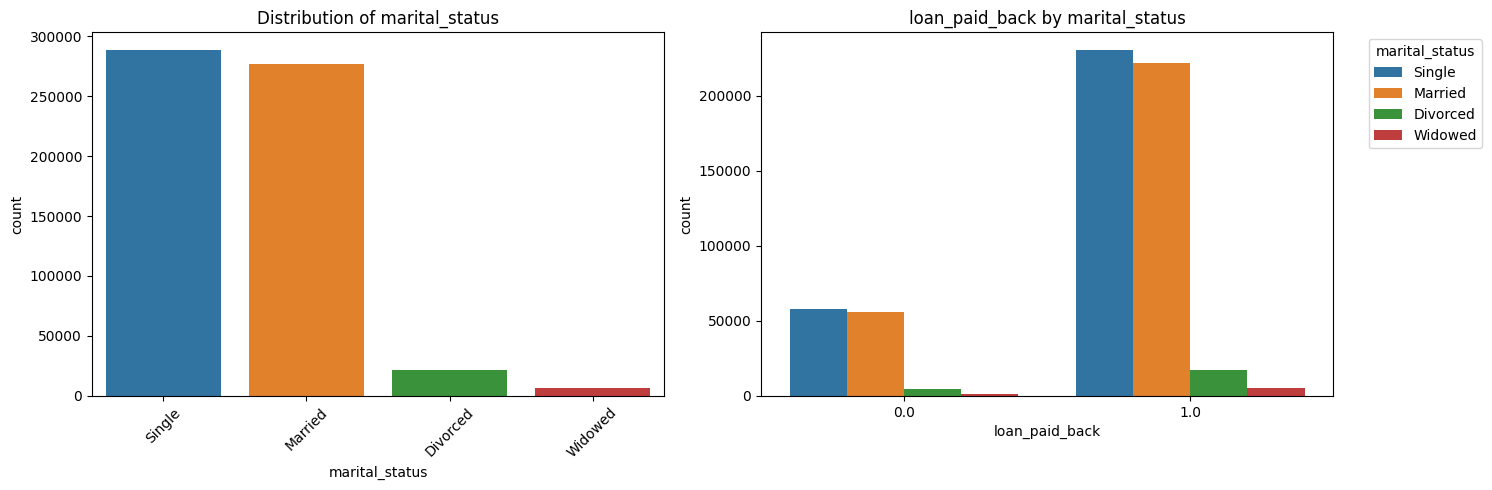

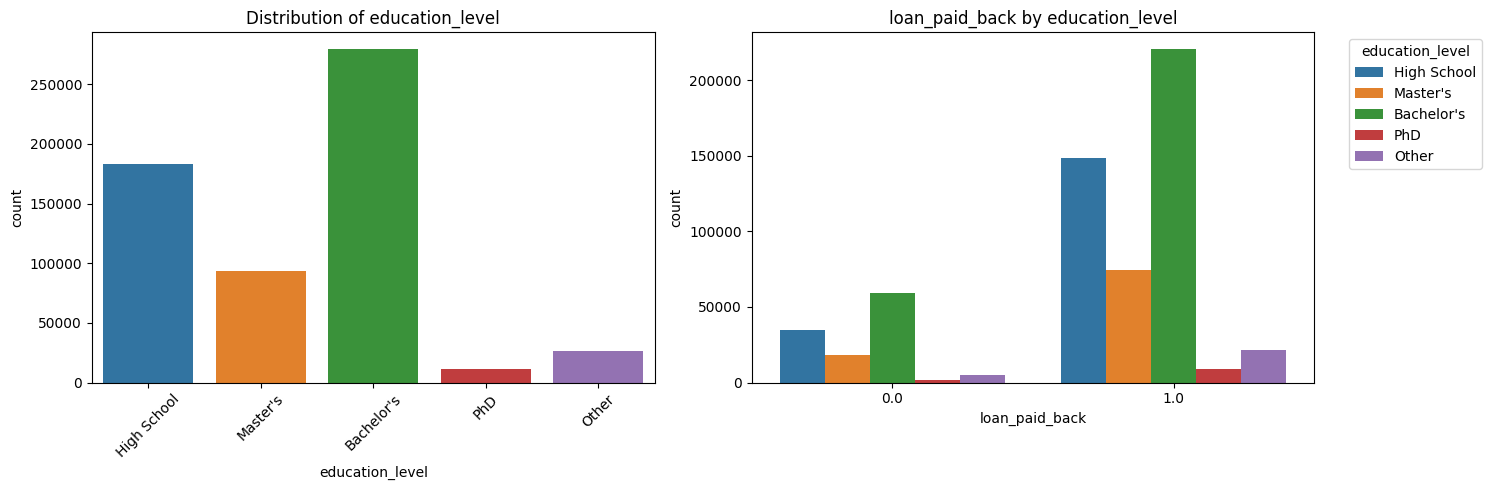

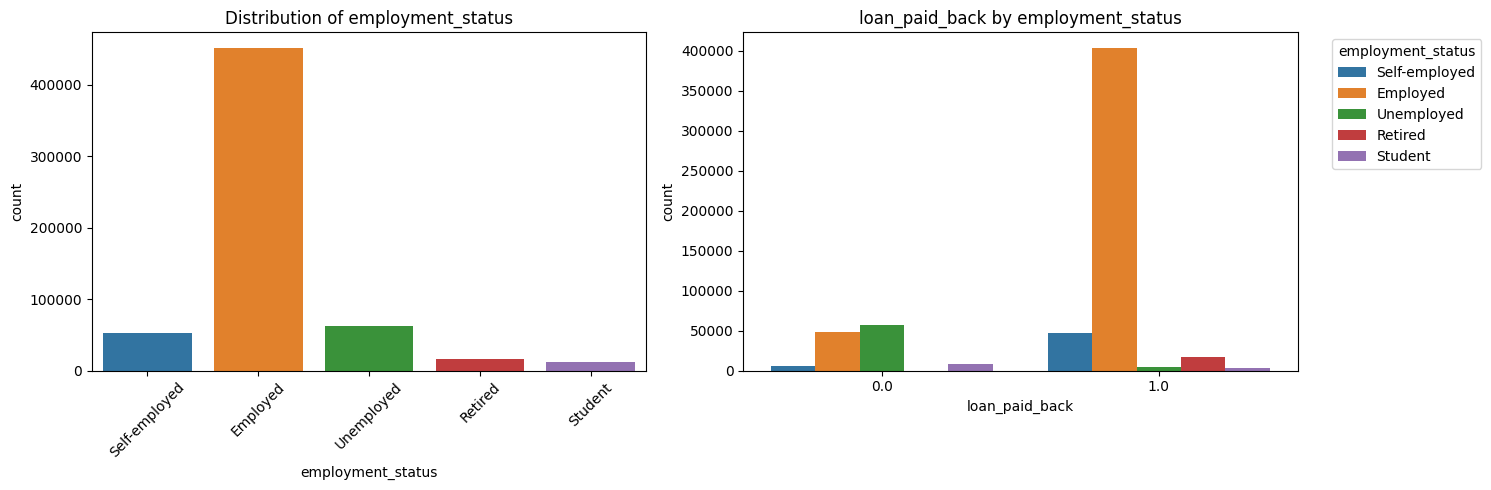

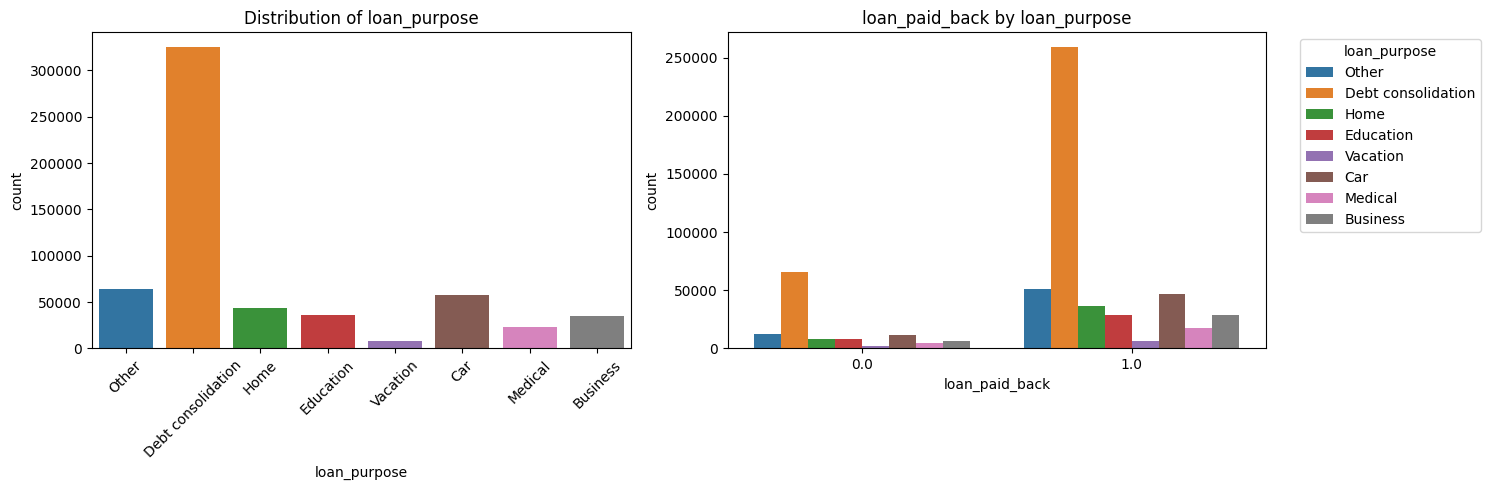

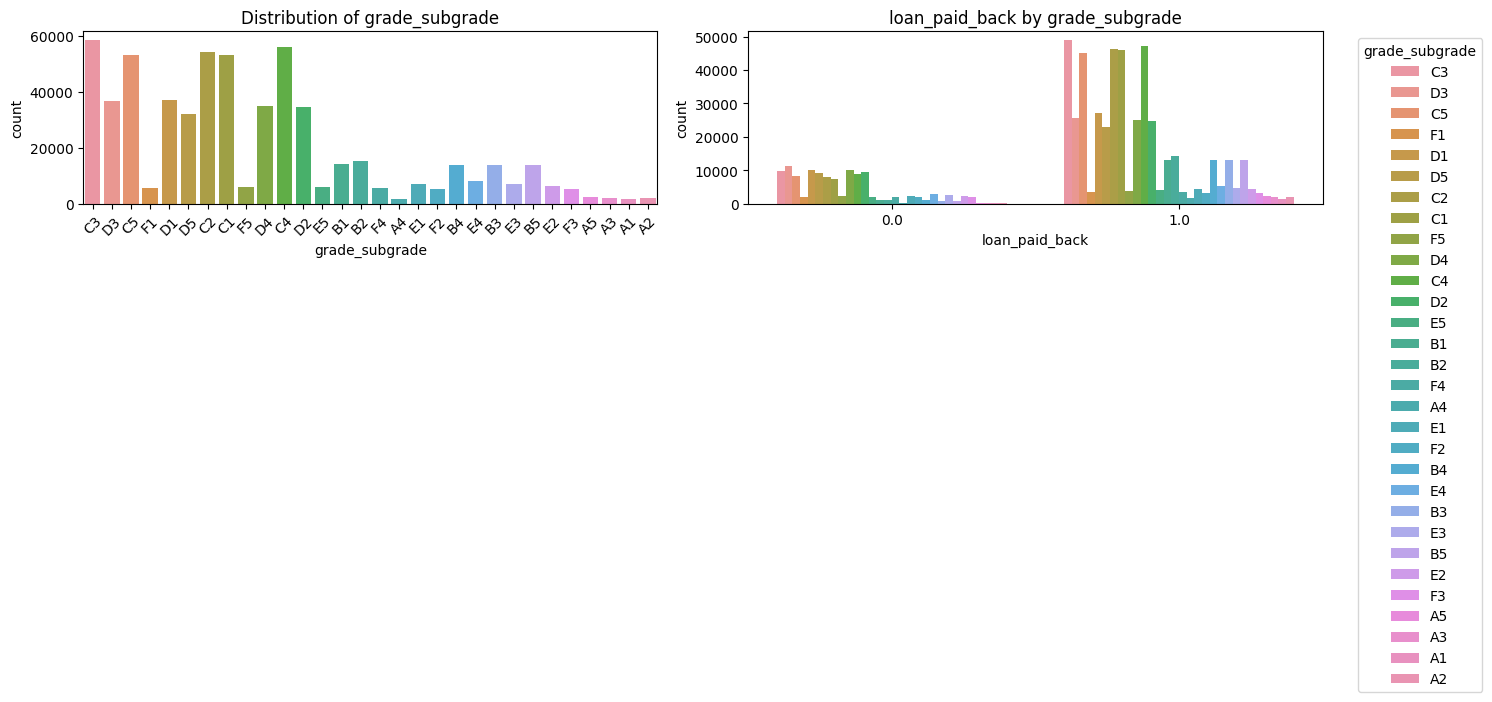

In [7]:
def plot_features_automatically(df, target_col='loan_paid_back'):
    # Identify feature types
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    
    # Remove target from numerical cols
    numerical_cols = [col for col in numerical_cols if col != target_col]
    
    print(f"Plotting {len(numerical_cols)} numerical features and {len(categorical_cols)} categorical features")
    
    # Plot numerical features
    for col in numerical_cols:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        sns.histplot(data=df, x=col, kde=True, ax=ax1)
        ax1.set_title(f'Distribution of {col}')
        
        sns.boxplot(data=df, x=target_col, y=col, ax=ax2)
        ax2.set_title(f'{col} vs {target_col}')
        
        plt.tight_layout()
        plt.show()
    
    # Plot categorical features
    for col in categorical_cols:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        sns.countplot(data=df, x=col, ax=ax1)
        ax1.set_title(f'Distribution of {col}')
        ax1.tick_params(axis='x', rotation=45)
        
        sns.countplot(data=df, x=target_col, hue=col, ax=ax2)
        ax2.set_title(f'{target_col} by {col}')
        ax2.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.show()

# Usage
plot_features_automatically(train_df, 'loan_paid_back')

In [8]:
train_df_2 = train_df[(train_df['annual_income'] < 200000) & 
        (train_df['debt_to_income_ratio'] < 0.4) &
        (train_df['credit_score'] < 500) &
        (train_df['loan_amount'] < 35000) &
        (train_df['interest_rate'] > 6) & (train_df['interest_rate'] < 19)] 

Plotting 6 numerical features and 6 categorical features


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


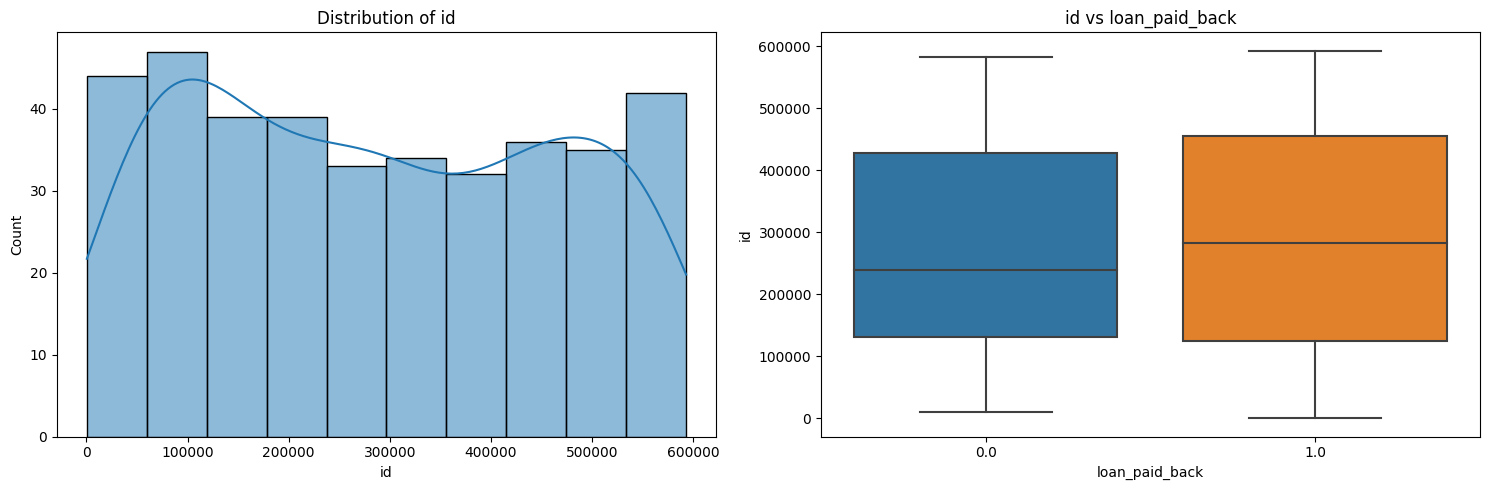

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


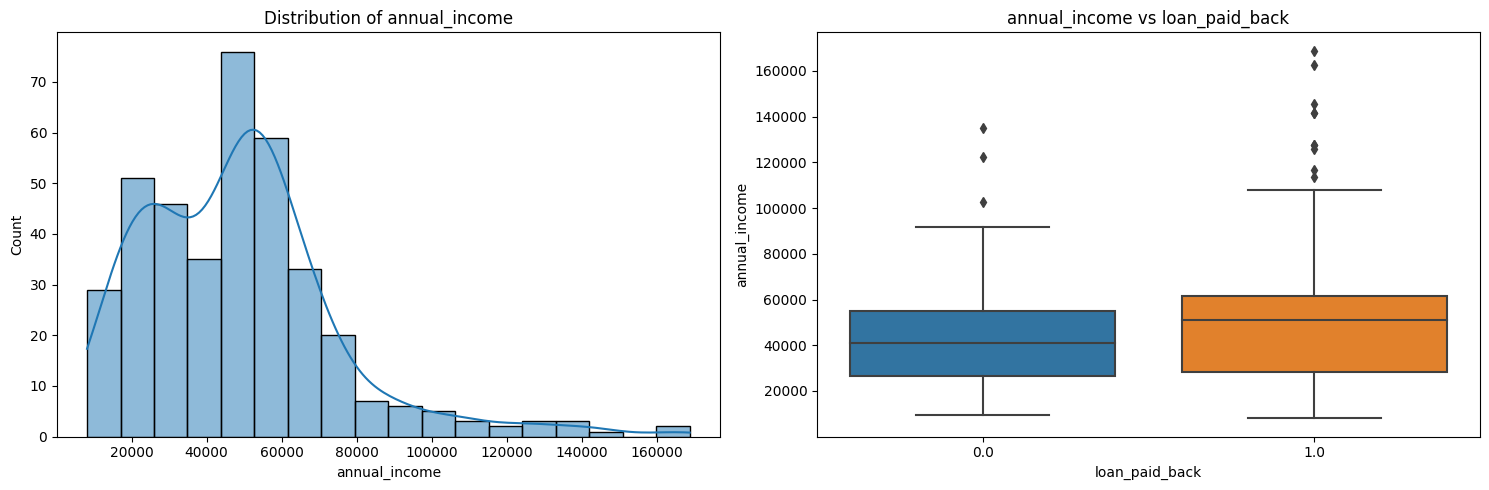

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


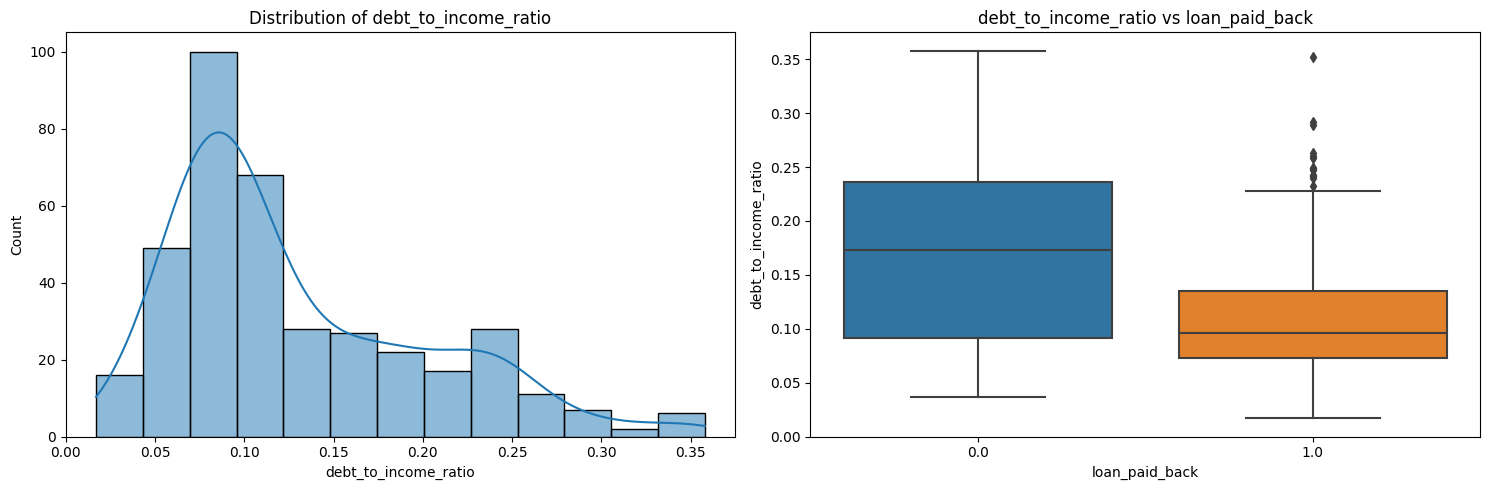

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


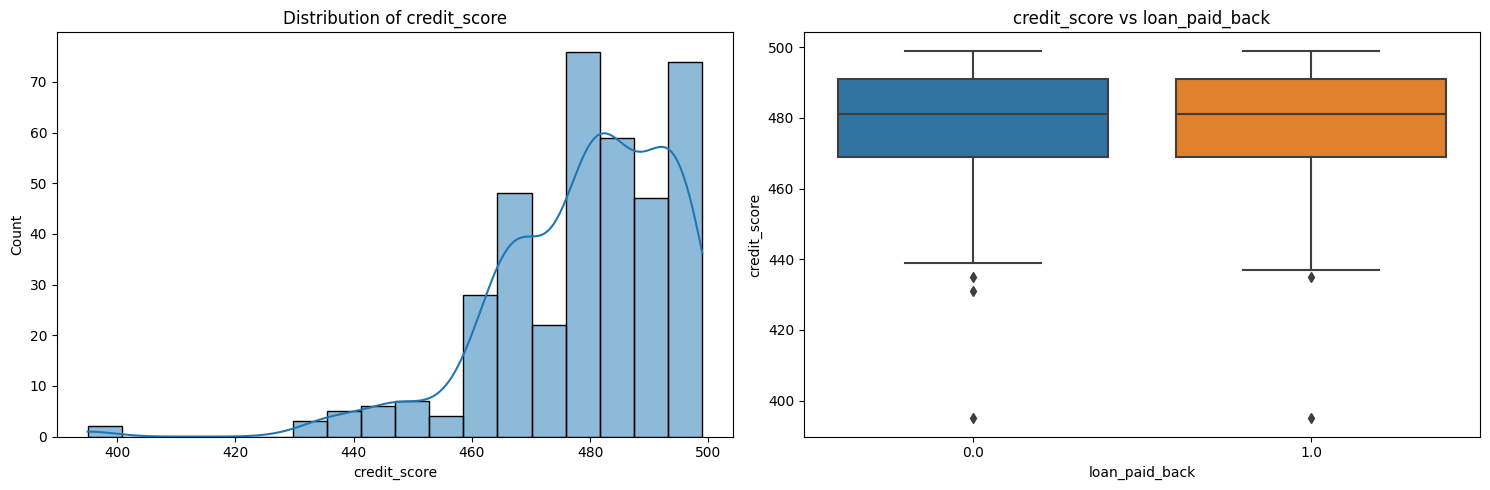

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


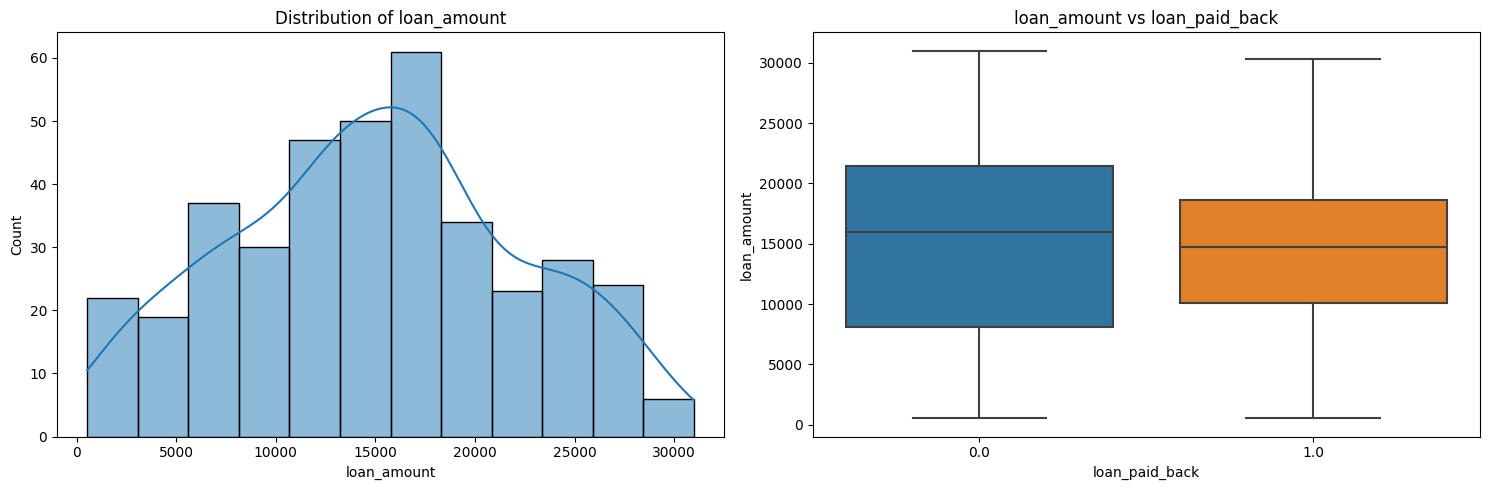

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


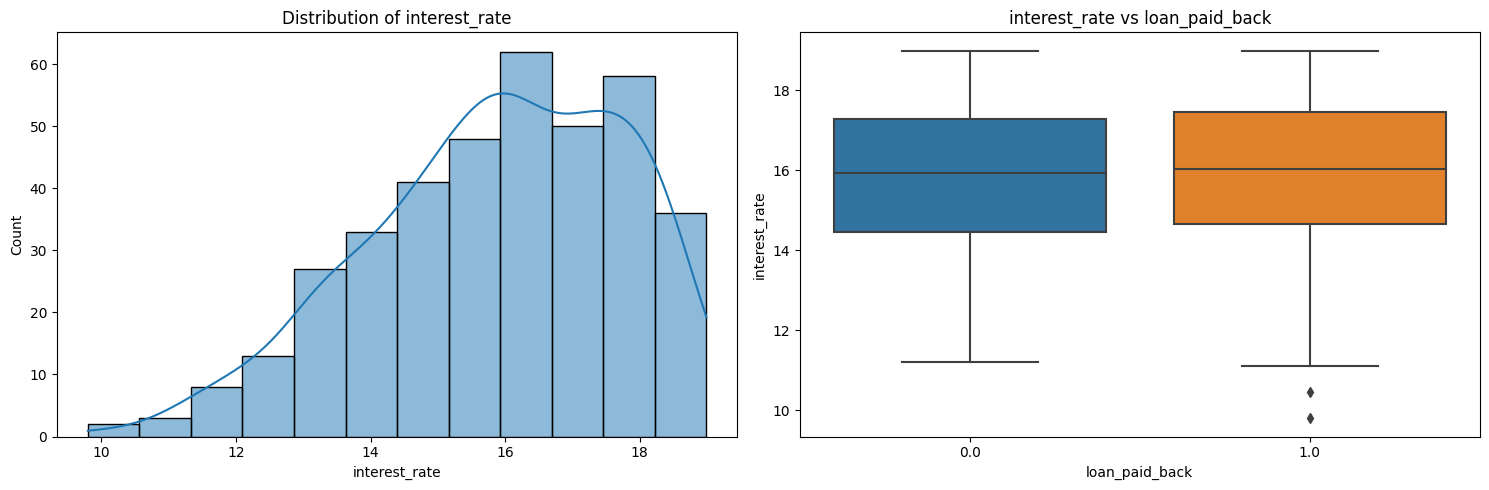

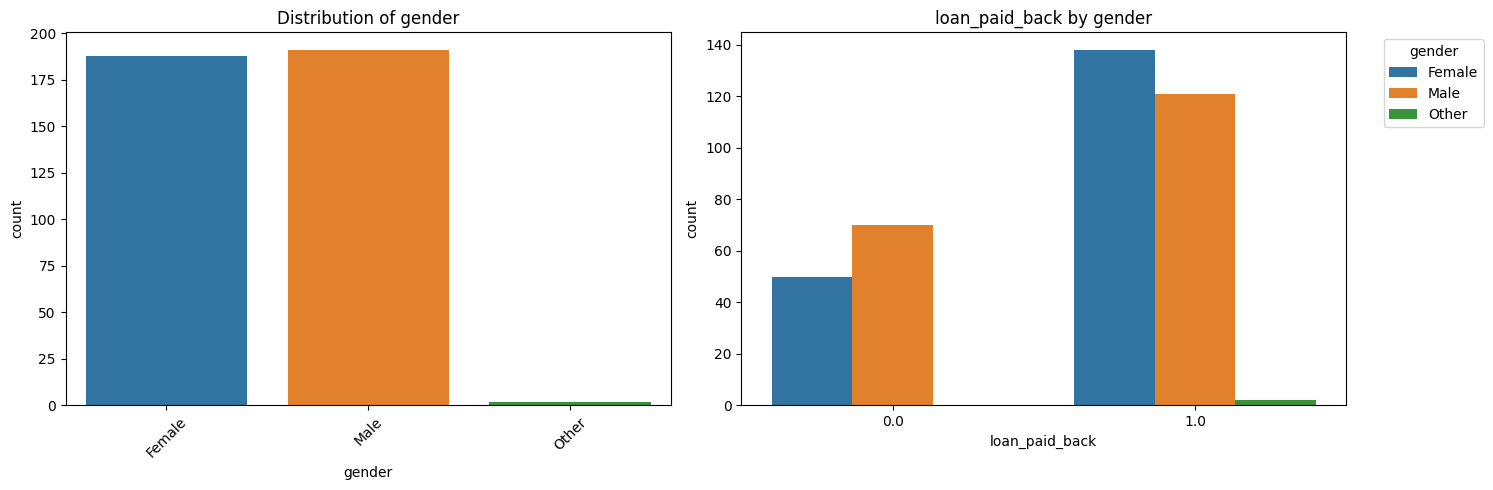

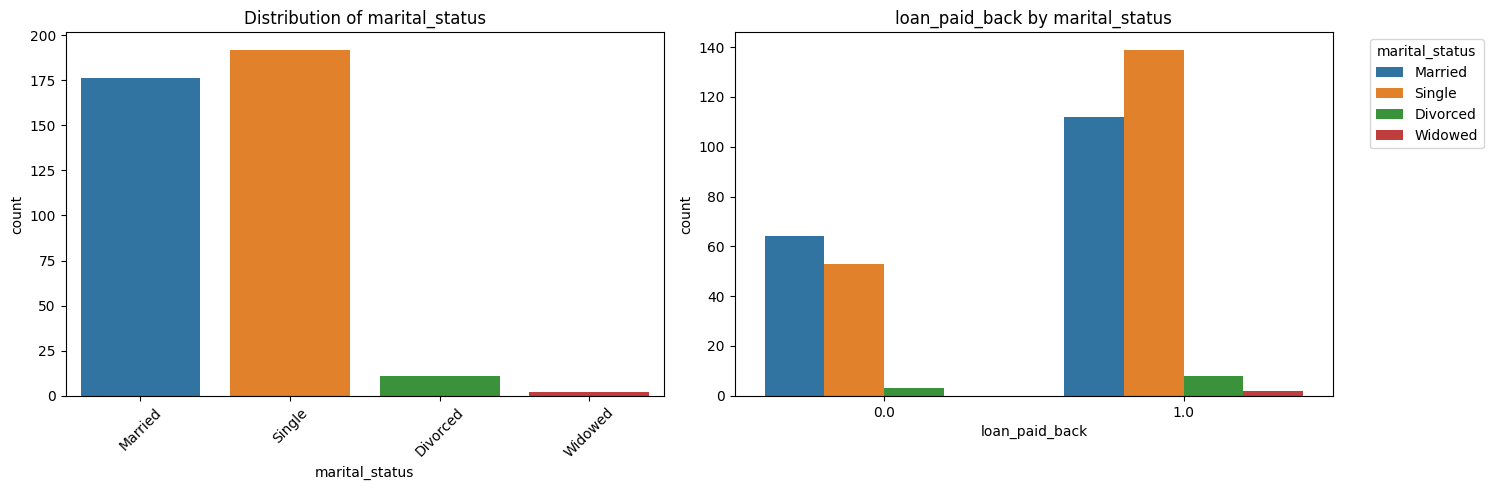

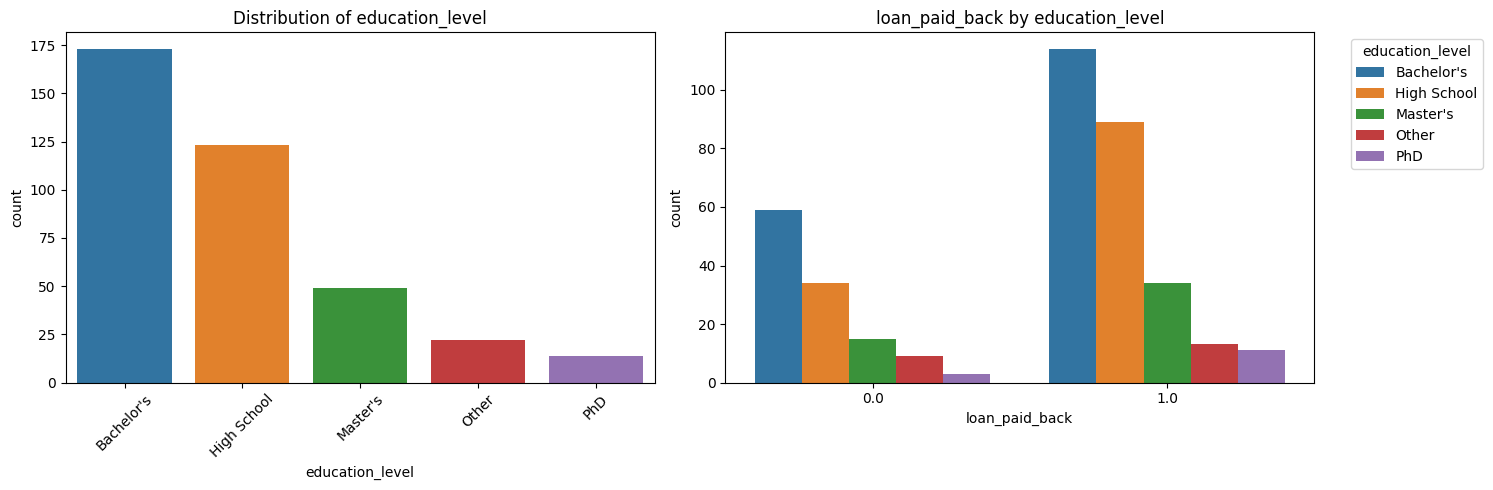

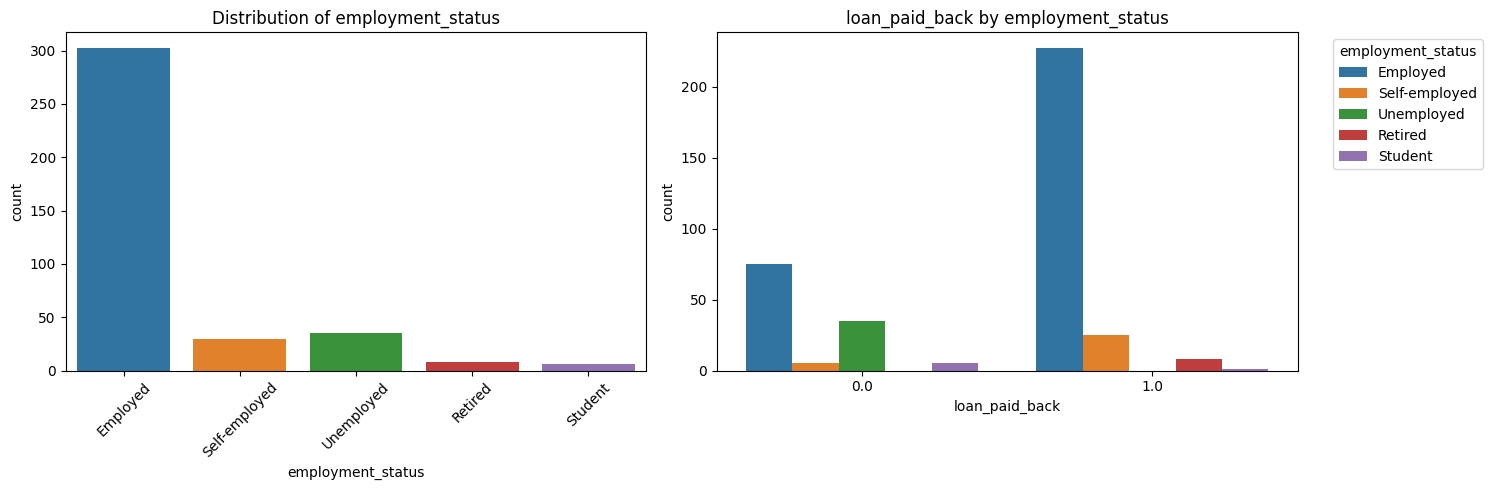

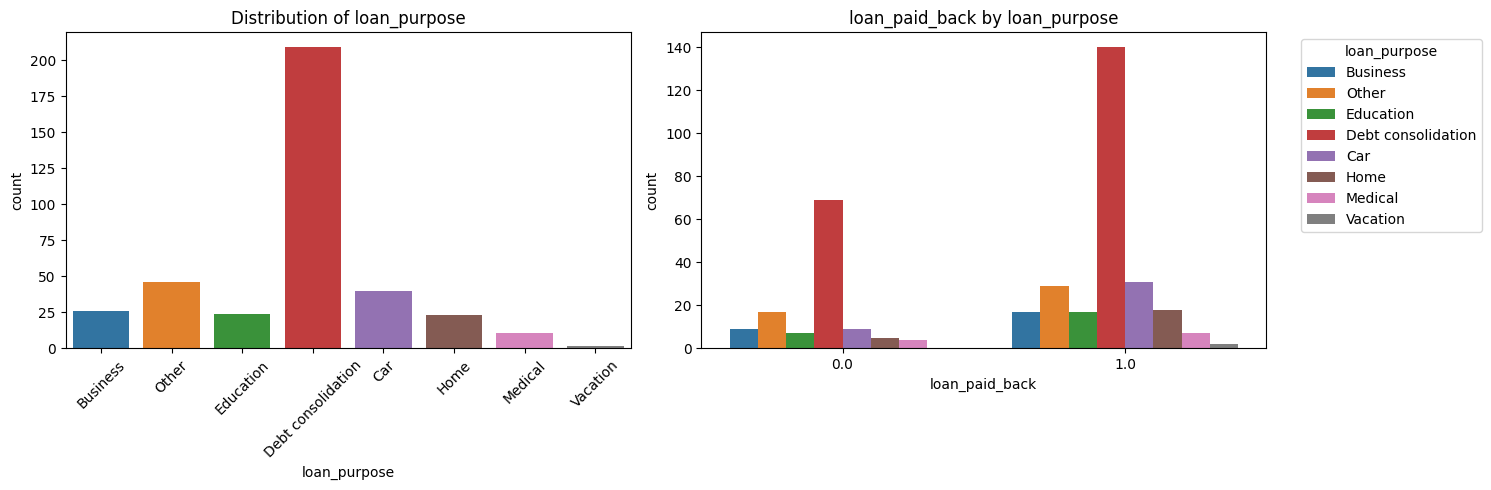

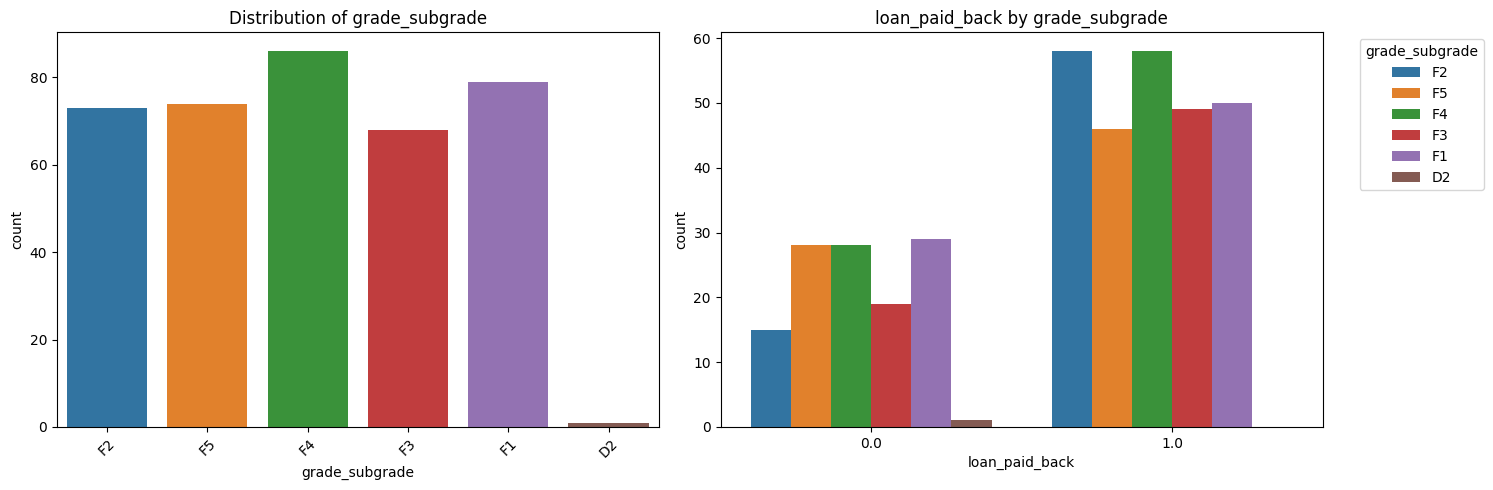

In [9]:
# Usage
plot_features_automatically(train_df_2, 'loan_paid_back')

In [10]:
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 5,
    'colsample_bytree': 0.5,
    'subsample': 0.8,
    'n_estimators': 10000,
    'early_stopping_rounds': 50,
    'learning_rate': 0.01,
    'random_state': 42,
    'n_jobs': -1,
    'enable_categorical': True,
}

In [11]:
train_df.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

In [12]:
y = train_df['loan_paid_back']
X = train_df.drop(columns=['id', 'loan_paid_back'])

In [13]:
test_df = pd.read_csv('/kaggle/input/playground-series-s5e11/test.csv')
test = test_df.copy()
test.drop(columns='id', inplace=True)

In [14]:
test

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1
...,...,...,...,...,...,...,...,...,...,...,...
254564,92835.97,0.068,744,29704.00,13.48,Female,Single,Bachelor's,Employed,Debt consolidation,B2
254565,48846.47,0.091,634,20284.33,9.58,Female,Married,High School,Employed,Debt consolidation,D4
254566,20668.52,0.096,718,26387.55,9.00,Male,Single,Master's,Employed,Debt consolidation,C4
254567,34105.09,0.094,739,11107.36,9.81,Male,Single,Bachelor's,Employed,Business,C2


In [15]:
# Assuming you have these defined
# X, y, test, CATS (list of categorical columns), params

N_SPLITS = 5
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))

# Initialize KFold
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{N_SPLITS} ---')
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Convert categorical columns - do this BEFORE splitting to avoid data leakage
    X_train_cat = X_train.copy()
    X_val_cat = X_val.copy()
    test_cat = test.copy()
    
    X_train_cat[categorical_cols] = X_train_cat[categorical_cols].astype('category')
    X_val_cat[categorical_cols] = X_val_cat[categorical_cols].astype('category')
    test_cat[categorical_cols] = test_cat[categorical_cols].astype('category')

    # Initialize model with your parameters
    model = xgb.XGBClassifier(**params)
    
    # Train with early stopping
    model.fit(
        X_train_cat, y_train,
        eval_set=[(X_val_cat, y_val)],
        verbose=100  # Reduced from 1000 to see more frequent updates
    )

    # Get predictions
    val_preds = model.predict_proba(X_val_cat)[:, 1]
    oof_preds[val_idx] = val_preds
    
    # Test predictions for this fold
    fold_test_preds = model.predict_proba(test_cat)[:, 1]
    test_preds += fold_test_preds / N_SPLITS  # Average across folds
    
    fold_score = roc_auc_score(y_val, val_preds)
    print(f'Fold {fold} AUC: {fold_score:.4f}')
    print(f'Best iteration: {model.best_iteration}')
    print()

# Calculate overall OOF score
overall_auc = roc_auc_score(y, oof_preds)
print(f'====================')
print(f'Overall OOF AUC: {overall_auc:.4f}')
print(f'====================')

# Optional: Save OOF predictions and test predictions
oof_df = pd.DataFrame({
    'true_target': y,
    'oof_preds': oof_preds
})

test_predictions_df = pd.DataFrame({
    'preds': test_preds
})

--- Fold 1/5 ---
[0]	validation_0-auc:0.77886
[53]	validation_0-auc:0.91057
Fold 1 AUC: 0.9127
Best iteration: 3

--- Fold 2/5 ---
[0]	validation_0-auc:0.77870
[57]	validation_0-auc:0.90961
Fold 2 AUC: 0.9115
Best iteration: 7

--- Fold 3/5 ---
[0]	validation_0-auc:0.77632
[52]	validation_0-auc:0.90808
Fold 3 AUC: 0.9107
Best iteration: 3

--- Fold 4/5 ---
[0]	validation_0-auc:0.77535
[55]	validation_0-auc:0.90781
Fold 4 AUC: 0.9110
Best iteration: 5

--- Fold 5/5 ---
[0]	validation_0-auc:0.77760
[57]	validation_0-auc:0.90964
Fold 5 AUC: 0.9113
Best iteration: 7

Overall OOF AUC: 0.9037


In [16]:
test_predictions_df = pd.concat([test_df['id'], test_predictions_df], axis=1)

In [17]:
test_predictions_df

,id,preds
0,593994,0.771650
1,593995,0.776696
2,593996,0.759167
3,593997,0.775267
4,593998,0.775499
...,...,...
254564,848558,0.777950
254565,848559,0.771165
254566,848560,0.775993
254567,848561,0.777417
